# `PolynomialScheduler`

This notebook provides an empirical demonstration of the expected behavior of a `PolynomialScheduler`. Its purpose is to make the module's scheduling behavior observable in a simple setting in which it can be studied in isolation, rather than to exhaustively validate every implementation detail.

The capability examined is polynomial scheduling across depth. A `PolynomialScheduler` changes its value according to a polynomial relationship as depth increases, while respecting the configured lower and upper bounds.

## Conceptual Overview

A `PolynomialScheduler` defines a polynomial relationship between depth and scheduled value. For coefficients $c_0, c_1, \ldots, c_n$, the unconstrained value at depth $d$ is

$$
S(d)=\sum_{i=0}^{n} c_i d^i.
$$

Each coefficient determines the contribution of its corresponding power of depth, allowing the shape and rate of change of the schedule to vary across the evaluated range. The configured minimum and maximum values bound the schedule within the permitted range.

### Scope of the demonstration

The experiment evaluates a `PolynomialScheduler` over a finite range of depths and visualizes the resulting schedule.

In [1]:
import matplotlib.pyplot as plt

from jacinta.utils.scheduler import PolynomialScheduler

## Configuration

The parameters below are chosen to make the relevant behavior visible, but they should not be interpreted as general-purpose defaults.

`COEFFICIENTS = (0, 0, 0.00003, -0.000000002)` defines the coefficients of the constant, linear, quadratic, and cubic terms, respectively.

`MIN_VALUE = 0` and `MAX_VALUE = 1000` define the lower and upper bounds of the schedule.

`MAX_DEPTH = 10000` determines the range over which the schedule is visualized. It does not affect the scheduler itself.

In [2]:
# hyperparameters
COEFFICIENTS = (0, 0, 0.00003, -0.000000002)
MIN_VALUE = 0
MAX_VALUE = 1000

# plot parameters
MAX_DEPTH = 10000

## Visualization Utilities

The `PolynomialScheduler` can be evaluated directly at a requested depth. The following helper exposes that mapping for visualization.

`plot_scheduler()` evaluates the scheduler at every depth from zero through `MAX_DEPTH` and plots the resulting schedule. This provides a direct view of its behavior across the displayed range.

In [3]:
def plot_scheduler(
    ax: plt.Axes,
    scheduler: PolynomialScheduler,
) -> None:
    """
    Plot a scheduler.

    Args:
        ax (plt.Axes): The axes to plot on.
        scheduler (PolynomialScheduler): The scheduler to plot.
    """
    # evaluate the scheduler
    depths = list(range(MAX_DEPTH + 1))
    values = [scheduler(depth) for depth in depths]
    # plot the scheduler
    ax.plot(depths, values)
    ax.set_xlim(0, MAX_DEPTH)
    ax.set_xlabel("Depth")
    ax.set_ylabel("Value")
    ax.set_title(
        f"Polynomial Scheduler "
        f"(coefficients={COEFFICIENTS}, min_value={MIN_VALUE}, "
        f"max_value={MAX_VALUE})"
    )
    ax.grid(visible=True, alpha=0.3)
    return

## Evaluation

The plot shows the scheduled value increasing from `0` at depth `0`, through `500` at depth `5000`, to `1000` at depth `10000`. The increase is initially gradual, becomes progressively steeper toward the middle of the displayed range, and then becomes increasingly gradual again as the schedule approaches its upper endpoint.

The changing curvature confirms that the rate of change first increases and then decreases across depth while the schedule remains within its configured bounds.

In [4]:
# initialize a PolynomialScheduler
scheduler = PolynomialScheduler(
    coefficients=COEFFICIENTS,
    min_value=MIN_VALUE,
    max_value=MAX_VALUE,
)

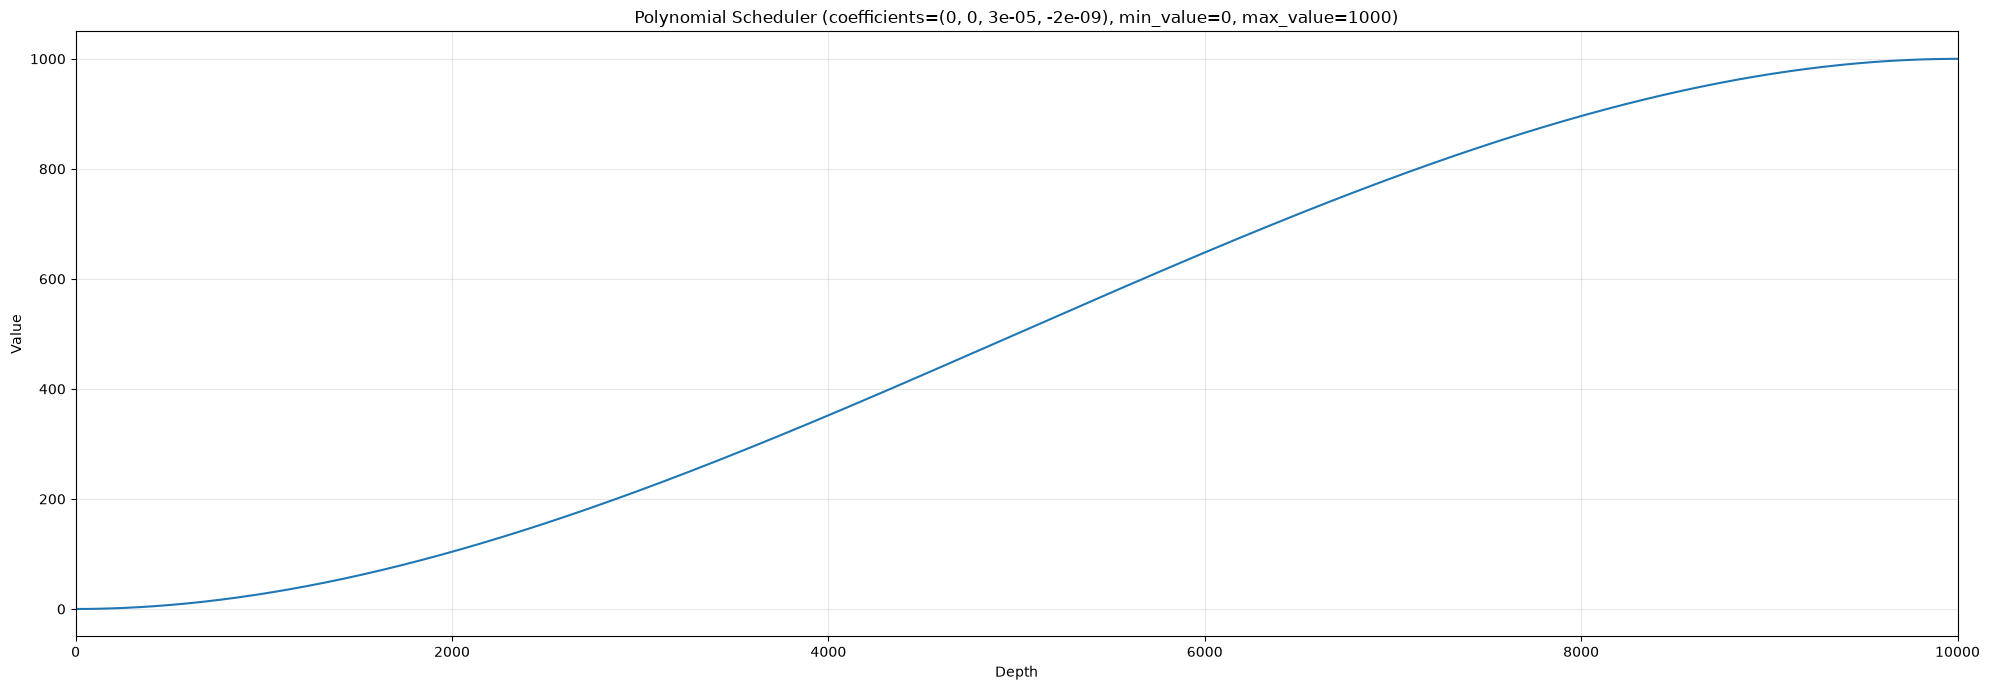

In [5]:
# plot the scheduler
fig, ax = plt.subplots(figsize=(20, 7))
plot_scheduler(ax, scheduler)
fig.tight_layout()
plt.show()

## Conclusions

This playground provides an empirical view of how a `PolynomialScheduler` maps depth to a value whose behavior is determined by a collection of polynomial coefficients. Their combined contributions allow both the shape and rate of change of the schedule to vary across depth, while the minimum and maximum values constrain the resulting schedule.

Examined in isolation, the module exhibits its intended behavior: it implements a bounded polynomial scheduling strategy in which the scheduled value follows the shape defined by its configured coefficients.